### aim: CFLX/ PPINT/ EXP see clim-assemblage for extraction

### date: 

In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [2]:
# ================================
# IMPORTS
# ================================
import os
import glob
import pickle
import time
import warnings
from datetime import datetime
from importlib import reload

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import seawater

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath

import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cmocean import cm

# Jupyter magic
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# ================================
# FONT CONFIGURATION
# ================================
# Disable LaTeX (use mathtext with chosen font)
plt.rcParams['text.usetex'] = False

# Base font size
fs = 11

# Path to Gill Sans
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Try to load custom font
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")

# Apply font settings
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

✓ Using custom font: Gill Sans


In [3]:
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')
cdomask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/windAnalyis/wspdComponents/PlankTOMmask_regridrecalc.nc')
tmask = cdomask.tmask

In [4]:
#kostelec - polsko
kostelec_6 = ['#C94B3C', '#E47A5C', '#A8B89C', '#6B9B7D', '#7FA4B8', '#4A3830']
kostelec_12 = ['#B23D32', '#C94B3C', '#E47A5C', '#D89B7A', '#E5C9A8', '#C8D4B8', '#A8B89C', '#6B9B7D', '#7FA4B8', '#5B7A8C', '#4A3830', '#2A1F1A']

#prachov - jezero 
prachovjezero_6 = ['#E85A2A', '#F4A63D', '#6B8C3E', '#5B9BAD', '#4A6B8A', '#6B3428']
prachovjezero_12 = ['#D84B28', '#E85A2A', '#F27435', '#F4A63D', '#D4B665', '#89A648', '#6B8C3E', '#4E7054', '#5B9BAD', '#4A6B8A', '#6B3428', '#3D2820']

# Tatry 
tatry_6 = ['#9B7850', '#D4C8A8', '#5B7F68', '#7BA6BC', '#A8BECF', '#3A4F3C']
tatry_12 = ['#7A5F40', '#9B7850', '#C4B090', '#E5D8B8', '#B8D090', '#8FAB80', '#5B7F68', '#5B7B7C', '#7BA6BC', '#A8BECF', '#3A4F3C', '#2B3A2E']
#cesky raj
ceskyraj_6 = ['#B8734E', '#D4A562', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#3A2F28']
ceskyraj_12 = ['#A85C3C', '#B8734E', '#D49558', '#D4A562', '#E5C485', '#9CB68A', '#6B8B72', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#5B3F4A', '#3A2F28']

## prachov - skaly
prachovskaly_6 = ['#B8844E', '#D4A865', '#6B8B5C', '#4B7B8C', '#2B5B8C', '#1B3F5C']
prachovskaly_12 = ['#9B6B3C', '#B8844E', '#C89B5A', '#D4A865', '#E5C68A', '#8BA872', '#6B8B5C', '#4B6B5A', '#5B8B9C', '#4B7B8C', '#2B5B8C', '#1B3F5C']

## jested lanovka
jested_6 = ['#D86B45', '#D4B870', '#8FAB7C', '#5B7B8C', '#6B8BAC', '#3A5B48']
jested_12 = ['#C85B3A', '#D86B45', '#E59B58', '#D4B870', '#E5D090', '#B8C88C', '#8FAB7C', '#6B8B78', '#5B7B8C', '#6B8BAC', '#4B6B5C', '#3A5B48']

## krkonose 
krkonose_6 = ['#E5A542', '#C4D858', '#6B8B5C', '#4B6B8C', '#7A9BAC', '#8B6B47']
krkonose_12 = ['#B87A3C', '#E5A542', '#F5C855', '#D4DB6A', '#C4D858', '#A8C850', '#6B8B5C', '#5B7B6C', '#4B6B8C', '#7A9BAC', '#8B6B47', '#5B4B38']

## dumbier
dumbier_6 = ['#D87845', '#E5C8A0', '#4B7BC2', '#6B9BD8', '#7AB8E5', '#1A2B3A']
dumbier_12 = ['#C86838', '#D87845', '#E59B68', '#E5C8A0', '#F5E8D0', '#A8C8E5', '#7AB8E5', '#6B9BD8', '#4B7BC2', '#3A5B8C', '#2A3B5C', '#1A2B3A']

## assorted snippets

#### notebook footer

In [5]:
def add_notebook_footer(fig, notebook_name, path_y_position=0.02):
    """
    Add notebook path as footer to figure with automatic spacing.
    
    Parameters:
    -----------
    fig : matplotlib figure object
    notebook_name : str
        Name of the notebook file (e.g., 'AMOCts.ipynb')
    path_y_position : float
        Y position for the footer text (default 0.02 = 2% from bottom)
        
    usage 
    bottom_margin = add_notebook_footer(fig, 'AMOCts.ipynb')
    plt.tight_layout(rect=[0, bottom_margin, 1, 0.96])    
    """
    notebook_path = os.path.abspath(os.getcwd())
    full_notebook_path = os.path.join(notebook_path, notebook_name)
    fig.text(0.5, path_y_position, f'Notebook: {full_notebook_path}', ha='center', 
             fontsize=10, style='italic', color='gray')
    
    # Return the bottom margin needed for tight_layout
    return path_y_position + 0.05  # Add buffer above text

#### tylist

In [6]:
def make_yearlist(yrst, yrend, dtype, tr, baseDir):
    yrs = np.arange(yrst,yrend+1,1)
    ylist = []
    for i in range(0,len(yrs)):
        ty = f'{baseDir}/{tr}/ORCA2_1m_{yrs[i]}*{dtype}*.nc'
        t2 = glob.glob(ty)
        #print(t2)
        ylist.append(t2[0])
    return ylist

## id runs and load climatology

In [7]:
BASE = 'TOM12_TJ_LA50'
HOSE = 'TOM12_TJ_LAH3'
CCLIM = 'TOM12_TJ_LA50'



In [8]:
bdir = '/gpfs/data/greenocean/software/runs/'
BASE_diad = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_diad_T.nc')
HOSE_diad = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_diad_T.nc')

days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

# Convert to seconds
seconds_per_month = np.array(days_per_month) * 24 * 60 * 60

# Create 1-D xarray
seconds_per_month_xr = xr.DataArray(
    seconds_per_month,
    dims=['time'],
    name='seconds_per_month'
)

masks = ['A1','A2','A3','A4','A5','ATL','NATL']
mask['NATL'] = mask['A1'] + mask['A2']


# Multiply with your Cflx
print(f'global Cflx')
molar_mass_carbon = 12.01  # grams per mole
grams_to_petagrams = 1e-15  
yearly_cflx = BASE_diad.Cflx * seconds_per_month_xr * mask.csize * molar_mass_carbon * grams_to_petagrams #mol/m2/s * s * m2
print(f'BASE {np.nansum(yearly_cflx)}')
yearly_cflx = HOSE_diad.Cflx * seconds_per_month_xr * mask.csize * molar_mass_carbon * grams_to_petagrams #mol/m2/s * s * m2
print(f'HOSE {np.nansum(yearly_cflx)}')


print(f'global PPINT')
molar_mass_carbon = 12.01  # grams per mole
grams_to_petagrams = 1e-15  
yearly_cflx = BASE_diad.PPINT * seconds_per_month_xr * mask.csize * molar_mass_carbon * grams_to_petagrams #mol/m2/s * s * m2
print(f'BASE {np.nansum(yearly_cflx)}')
yearly_cflx = HOSE_diad.PPINT * seconds_per_month_xr * mask.csize * molar_mass_carbon * grams_to_petagrams #mol/m2/s * s * m2
print(f'HOSE {np.nansum(yearly_cflx)}')

print(f'global EXP')
molar_mass_carbon = 12.01  # grams per mole
grams_to_petagrams = 1e-15  
BASE_diad['EXP100'] = (BASE_diad.EXP[:,9,:,:] + BASE_diad.EXP[:,10,:,:])/2
HOSE_diad['EXP100'] = (HOSE_diad.EXP[:,9,:,:] + BASE_diad.EXP[:,10,:,:])/2
yearly_cflx = BASE_diad.EXP100 * seconds_per_month_xr * mask.csize * molar_mass_carbon * grams_to_petagrams #mol/m2/s * s * m2
print(f'BASE {np.nansum(yearly_cflx)}')
yearly_cflx = HOSE_diad.EXP100 * seconds_per_month_xr * mask.csize * molar_mass_carbon * grams_to_petagrams #mol/m2/s * s * m2
print(f'HOSE {np.nansum(yearly_cflx)}')

#BASE_diad_rg = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')

global Cflx
BASE 2.378876270320747
HOSE 2.3348289273509
global PPINT
BASE 46.506416670050875
HOSE 44.707003915751045
global EXP
BASE 5.362050407129295
HOSE 5.319376102958858


## calculate 

In [9]:
bdir = '/gpfs/data/greenocean/software/runs/'
BASE_diad = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_diad_T.nc')
HOSE_diad = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_diad_T.nc')

days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
seconds_per_month = np.array(days_per_month) * 24 * 60 * 60
seconds_per_month_xr = xr.DataArray(
    seconds_per_month,
    dims=['time'],
    name='seconds_per_month'
)

# Define regions
masks_dict = {}
masks_dict['GLOBE'] = mask.csize
masks_dict['ATL'] = mask['ATL'] * mask.csize
masks_dict['NATL'] = (mask['A1'] + mask['A2']) * mask.csize

# Conversion factors
molar_mass_carbon = 12.01  # grams per mole
grams_to_petagrams = 1e-15

# Calculate EXP100 (average of layers 9 and 10)
BASE_diad['EXP100'] = (BASE_diad.EXP[:,9,:,:] + BASE_diad.EXP[:,10,:,:])/2
HOSE_diad['EXP100'] = (HOSE_diad.EXP[:,9,:,:] + HOSE_diad.EXP[:,10,:,:])/2

# Metrics to calculate
metrics = ['Cflx', 'PPINT', 'EXP100']
regions = ['GLOBE', 'ATL', 'NATL']

# Calculate and print results
for metric in metrics:
    print(f"\n{metric}:")
    
    for region in regions:
        print(f"\n{'='*60}")
        print(f"REGION: {region}")
        print(f"{'='*60}")

        region_mask = masks_dict[region]
    

        
        # Calculate BASE
        yearly_base = BASE_diad[metric] * seconds_per_month_xr * region_mask * molar_mass_carbon * grams_to_petagrams
        base_total = np.nansum(yearly_base)
        
        # Calculate HOSE
        yearly_hose = HOSE_diad[metric] * seconds_per_month_xr * region_mask * molar_mass_carbon * grams_to_petagrams
        hose_total = np.nansum(yearly_hose)
        
        # Calculate change
        change = hose_total - base_total
        percent_change = (change / base_total) * 100 if base_total != 0 else 0
        
        print(f"  BASE: {base_total:.4f} Pg C/year")
        print(f"  HOSE: {hose_total:.4f} Pg C/year")
        print(f"  Change: {change:+.4f} Pg C/year ({percent_change:+.2f}%)")

print(f"\n{'='*60}")


Cflx:

REGION: GLOBE
  BASE: 2.3789 Pg C/year
  HOSE: 2.3348 Pg C/year
  Change: -0.0440 Pg C/year (-1.85%)

REGION: ATL
  BASE: 0.5968 Pg C/year
  HOSE: 0.5246 Pg C/year
  Change: -0.0722 Pg C/year (-12.11%)

REGION: NATL
  BASE: 0.2143 Pg C/year
  HOSE: 0.1321 Pg C/year
  Change: -0.0822 Pg C/year (-38.36%)

PPINT:

REGION: GLOBE
  BASE: 46.5064 Pg C/year
  HOSE: 44.7070 Pg C/year
  Change: -1.7994 Pg C/year (-3.87%)

REGION: ATL
  BASE: 13.0119 Pg C/year
  HOSE: 11.3875 Pg C/year
  Change: -1.6244 Pg C/year (-12.48%)

REGION: NATL
  BASE: 4.0614 Pg C/year
  HOSE: 3.4066 Pg C/year
  Change: -0.6548 Pg C/year (-16.12%)

EXP100:

REGION: GLOBE
  BASE: 5.3621 Pg C/year
  HOSE: 5.2864 Pg C/year
  Change: -0.0756 Pg C/year (-1.41%)

REGION: ATL
  BASE: 1.2654 Pg C/year
  HOSE: 1.1735 Pg C/year
  Change: -0.0920 Pg C/year (-7.27%)

REGION: NATL
  BASE: 0.3962 Pg C/year
  HOSE: 0.3371 Pg C/year
  Change: -0.0591 Pg C/year (-14.92%)



In [10]:
bdir = '/gpfs/data/greenocean/software/runs/'
BASE_ptrc = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc')
HOSE_ptrc = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc')


In [11]:
BASE_diad

<xarray.Dataset>
Dimensions:        (axis_nbounds: 2, deptht: 31, time: 12, x: 182, y: 149)
Coordinates:
    nav_lat        (y, x) float32 ...
    nav_lon        (y, x) float32 ...
  * deptht         (deptht) float32 5.0 15.0 25.0 ... 4.25e+03 4.75e+03 5.25e+03
  * time           (time) int64 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: axis_nbounds, x, y
Data variables: (12/72)
    deptht_bounds  (time, deptht, axis_nbounds) float32 ...
    EXP            (time, deptht, y, x) float32 ...
    GRAMIC         (time, deptht, y, x) float32 ...
    GRAMES         (time, deptht, y, x) float32 ...
    GRAMAC         (time, deptht, y, x) float32 ...
    PPT            (time, deptht, y, x) float32 ...
    ...             ...
    lim8light_mix  (time, deptht, y, x) float32 ...
    lim8light_coc  (time, deptht, y, x) float32 ...
    lim8light_pic  (time, deptht, y, x) float32 ...
    lim8light_pha  (time, deptht, y, x) float32 ...
    lim8light_fix  (time, deptht, y, x) float32 ...
    EXP100         (time, y, x) float32 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan

In [12]:
bdir = '/gpfs/data/greenocean/software/runs/'
BASE_diad = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc')
HOSE_diad = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc')

BASE_diad['PHY'] = BASE_diad['DIA'] +BASE_diad['MIX'] +BASE_diad['COC'] +\
    BASE_diad['PIC'] +BASE_diad['PHA'] +BASE_diad['FIX']
HOSE_diad['PHY'] = HOSE_diad['DIA'] +HOSE_diad['MIX'] +HOSE_diad['COC'] +\
    HOSE_diad['PIC'] +HOSE_diad['PHA'] +HOSE_diad['FIX']

days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
seconds_per_month = np.array(days_per_month) * 24 * 60 * 60
seconds_per_month_xr = xr.DataArray(
    seconds_per_month,
    dims=['time'],
    name='seconds_per_month'
)

# Define regions
masks_dict = {}
masks_dict['GLOBE'] = mask.csize
masks_dict['ATL'] = mask['ATL'] * mask.csize
masks_dict['NATL'] = (mask['A1'] + mask['A2']) * mask.csize

# Conversion factors
molar_mass_carbon = 12.01  # grams per mole
grams_to_petagrams = 1e-15

# # Calculate EXP100 (average of layers 9 and 10)
# BASE_diad['EXP100'] = (BASE_diad.EXP[:,9,:,:] + BASE_diad.EXP[:,10,:,:])/2
# HOSE_diad['EXP100'] = (HOSE_diad.EXP[:,9,:,:] + HOSE_diad.EXP[:,10,:,:])/2

# Metrics to calculate
metrics = ['PHY']
regions = ['GLOBE', 'ATL', 'NATL']

# Calculate and print results
for metric in metrics:
    print(f"\n{metric}:")
    
    for region in regions:
        print(f"\n{'='*60}")
        print(f"REGION: {region}")
        print(f"{'='*60}")

        region_mask = masks_dict[region]
    

        
        # Calculate BASE
        yearly_base = BASE_diad[metric] * seconds_per_month_xr * region_mask * molar_mass_carbon * grams_to_petagrams
        base_total = np.nansum(yearly_base)
        
        # Calculate HOSE
        yearly_hose = HOSE_diad[metric] * seconds_per_month_xr * region_mask * molar_mass_carbon * grams_to_petagrams
        hose_total = np.nansum(yearly_hose)
        
        # Calculate change
        change = hose_total - base_total
        percent_change = (change / base_total) * 100 if base_total != 0 else 0
        
        print(f"  BASE: {base_total:.4f} Pg C/year")
        print(f"  HOSE: {hose_total:.4f} Pg C/year")
        print(f"  Change: {change:+.4f} Pg C/year ({percent_change:+.2f}%)")

print(f"\n{'='*60}")


PHY:

REGION: GLOBE
  BASE: 24695.5072 Pg C/year
  HOSE: 24017.9017 Pg C/year
  Change: -677.6055 Pg C/year (-2.74%)

REGION: ATL
  BASE: 6213.0235 Pg C/year
  HOSE: 5772.4469 Pg C/year
  Change: -440.5765 Pg C/year (-7.09%)

REGION: NATL
  BASE: 1877.5773 Pg C/year
  HOSE: 1835.4443 Pg C/year
  Change: -42.1330 Pg C/year (-2.24%)



## maps. change this to 2010-2019 rg nc when available 

In [13]:
BASE_diad['time'] = np.arange(1,13,1)

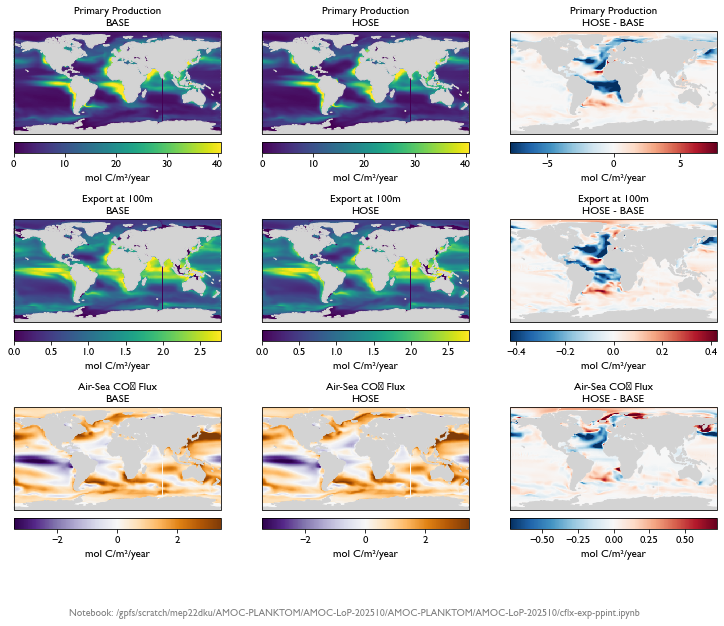

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

bdir = '/gpfs/data/greenocean/software/runs/'
BASE_diad = xr.open_dataset(f'{bdir}/{BASE}/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')
HOSE_diad = xr.open_dataset(f'{bdir}/{HOSE}/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')
BASE_diad['time'] = np.arange(1,13,1)
HOSE_diad['time'] = np.arange(1,13,1)

days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
seconds_per_month = np.array(days_per_month) * 24 * 60 * 60
seconds_per_month_xr = xr.DataArray(
    seconds_per_month,
    dims=['time'],
    name='seconds_per_month'
)

# Conversion factors
molar_mass_carbon = 12.01
grams_to_petagrams = 1e-15

# Calculate EXP100
BASE_diad['EXP100'] = (BASE_diad.EXP[:,9,:,:] + BASE_diad.EXP[:,10,:,:])/2
HOSE_diad['EXP100'] = (HOSE_diad.EXP[:,9,:,:] + HOSE_diad.EXP[:,10,:,:])/2

# Calculate yearly totals (summed over time) for plotting
# Reordered: PPINT, EXP100, Cflx (Cflx now at bottom)
metrics = ['PPINT', 'EXP100', 'Cflx']
metric_labels = ['Primary Production', 'Export at 100m', 'Air-Sea CO₂ Flux']
metric_units = ['mol C/m²/year', 'mol C/m²/year', 'mol C/m²/year']

# Create figure with 9 subplots (3 rows x 3 columns)
fact = 0.7
fig = plt.figure(figsize=(18*fact, 14*fact))

for i, (metric, label, unit) in enumerate(zip(metrics, metric_labels, metric_units)):
    # Calculate yearly fields
    base_yearly = (BASE_diad[metric] * seconds_per_month_xr).sum(dim='time')
    hose_yearly = (HOSE_diad[metric] * seconds_per_month_xr).sum(dim='time')
    diff_yearly = hose_yearly - base_yearly
    
    # Get coordinate arrays
    if 'lat' in BASE_diad and 'lon' in BASE_diad:
        lats = BASE_diad.lat.values
        lons = BASE_diad.lon.values
    else:
        # Fallback to y, x indices
        lats = BASE_diad.y.values
        lons = BASE_diad.x.values
    
    # Determine colorbar limits for BASE and HOSE (same scale)
    vmax = np.nanpercentile(np.maximum(np.abs(base_yearly), np.abs(hose_yearly)), 99)
    vmin = -vmax if metric == 'Cflx' else 0  # Cflx can be negative, others positive
    
    # Determine colorbar limits for difference (centered on 0)
    diff_max = np.nanpercentile(np.abs(diff_yearly), 99)
    
    # Choose colormaps
    # For Cflx (bottom row), use a different diverging colormap for BASE/HOSE
    if metric == 'Cflx':
        base_hose_cmap = 'PuOr_r'  # Different diverging colormap for Cflx
        diff_cmap = 'RdBu_r'  # Keep RdBu_r for differences
    else:
        base_hose_cmap = 'viridis'
        diff_cmap = 'RdBu_r'
    
    # Row index
    row = i
    
    # BASE (left column)
    ax1 = fig.add_subplot(3, 3, row*3 + 1, projection=ccrs.PlateCarree())
    ax1.coastlines()
    ax1.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
    im1 = ax1.pcolormesh(lons, lats, base_yearly, 
                         transform=ccrs.PlateCarree(),
                         vmin=vmin, vmax=vmax, cmap=base_hose_cmap)
    ax1.set_title(f'{label}\nBASE')
    plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, label=unit)
    
    # HOSE (center column)
    ax2 = fig.add_subplot(3, 3, row*3 + 2, projection=ccrs.PlateCarree())
    ax2.coastlines()
    ax2.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
    im2 = ax2.pcolormesh(lons, lats, hose_yearly,
                         transform=ccrs.PlateCarree(),
                         vmin=vmin, vmax=vmax, cmap=base_hose_cmap)
    ax2.set_title(f'{label}\nHOSE')
    plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, label=unit)
    
    # DIFFERENCE (right column)
    ax3 = fig.add_subplot(3, 3, row*3 + 3, projection=ccrs.PlateCarree())
    ax3.coastlines()
    ax3.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
    im3 = ax3.pcolormesh(lons, lats, diff_yearly,
                         transform=ccrs.PlateCarree(),
                         vmin=-diff_max, vmax=diff_max, cmap=diff_cmap)
    ax3.set_title(f'{label}\nHOSE - BASE')
    plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, label=unit)

plt.tight_layout()
add_notebook_footer(fig, 'AMOC-PLANKTOM/AMOC-LoP-202510/cflx-exp-ppint.ipynb', path_y_position=0.02)
plt.savefig('./plts/carbon_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## CFLX-EXP-PPINT timeseries/etc with new mask

    (swamp2) [mep22dku@compute077 ~/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/EXTRACT]$ python province_means.py

In [15]:
MA = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/mask_atl.nc')
MA_rg = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/mask_atl_rg.nc')
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')


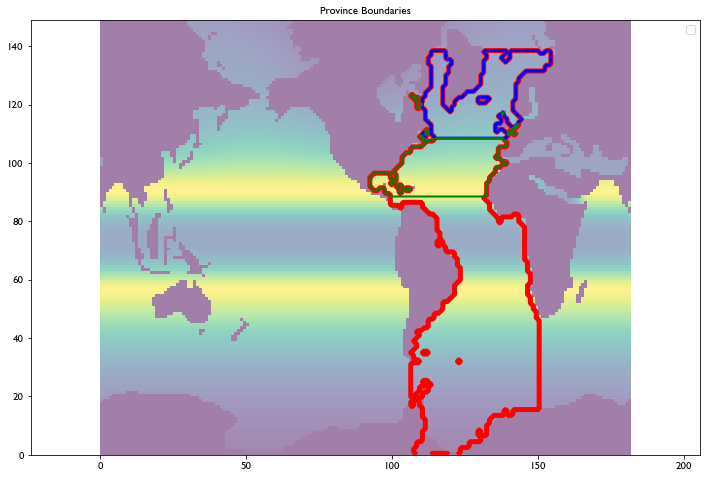

In [16]:
GO = mask.csize
AB = mask.csize * MA.AB
HA = mask.csize * MA.HA
NA = mask.csize * MA.NA

plt.figure(figsize=(12, 8))
plt.contour(MA.AB, levels=[0.5], colors='red', linewidths=5, zorder = 1)
plt.contour(MA.HA, levels=[0.5], colors='blue', linewidths=3, zorder = 2)
plt.contour(MA.NA, levels=[0.5], colors='green', linewidths=2, zorder = 3)
plt.pcolormesh(mask.csize, zorder = 0, alpha = 0.5)
plt.title('Province Boundaries')
plt.legend(['AB', 'HA', 'NA'])
plt.axis('equal')
plt.show()


In [33]:
MODELS = {
    'CCLIM': {
        'color': 'deepskyblue',  # Blue
        'id': 'TOM12_TJ_LC51'
    },
    'CCLIM2': {
        'color': 'royalblue',  # Purple
        'id': 'TOM12_TJ_LC52'
    },
    'HOSE': {
        'color': 'r',  # Orange
        'id': 'TOM12_TJ_LAH3'
    },
    'HIST': {
        'color': 'b',  # Red
        'id': 'TOM12_TJ_LA50'
    },
    
    'OBi1': {
        'color': 'g',  # Red
        'id': 'TOM12_RW_OBi1'
    }
    
}
bdir = '/gpfs/data/greenocean/users/mep22dku/clims/'


mods = ['CCLIM','HIST','HOSE']

hist = MODELS['HIST']['id']
HIST_AMOC = xr.open_dataset(f'{bdir}/{hist}/{hist}_AMOC_1940_2020.nc')
HIST_NO3 = xr.open_dataset(f'{bdir}/{hist}/{hist}_ptrc_NO3_d0_provinces.nc')



In [41]:
w = xr.open_dataset('/gpfs/data/greenocean/users/mep22dku/clims/TOM12_TJ_LC51/TOM12_TJ_LC51_diad_EXP100_dNone_provinces.nc')
w

<xarray.Dataset>
Dimensions:        (province: 4, time_counter: 1260)
Coordinates:
    deptht         float32 ...
    time_centered  (time_counter) object ...
  * time_counter   (time_counter) object 1920-01-16 12:00:00 ... 2024-12-16 1...
  * province       (province) object 'GO' 'AB' 'HA' 'NA'
Data variables:
    EXP            (province, time_counter) float32 ...

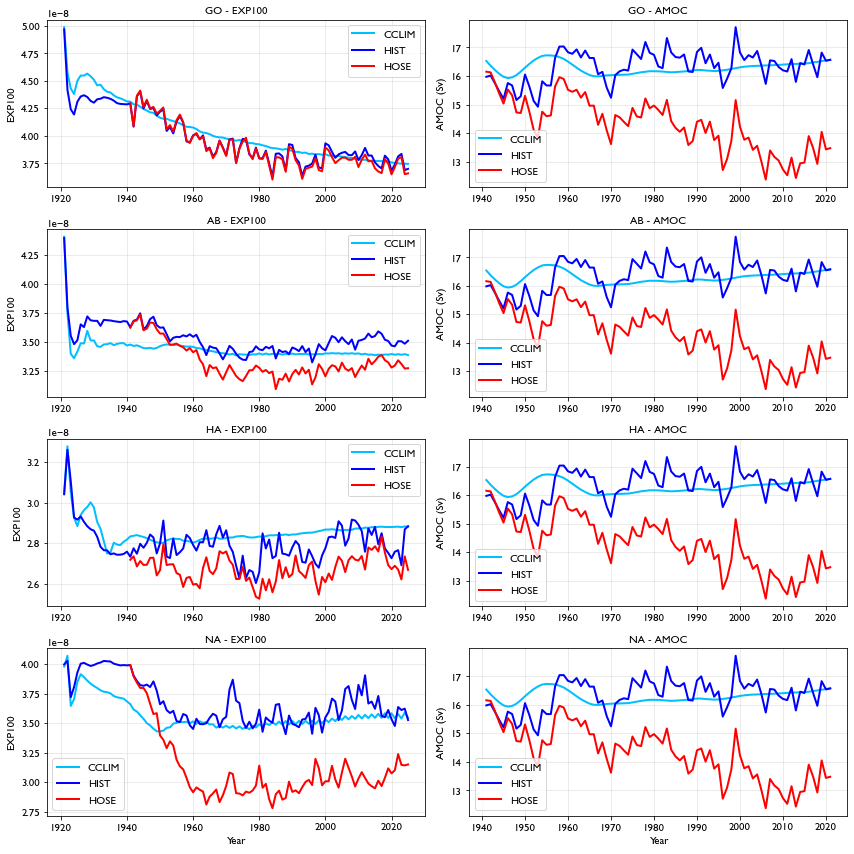

In [43]:
# Open datasets
NO3 = {}
AMOC = {}
tvar = 'EXP100'
tvar2 = 'EXP'
mods_nutrients = mods #+ ['OBi1']  # Add OBi1 for nutrients

for mod in mods_nutrients:
    mid = MODELS[mod]['id']
    try:
        NO3[mod] = xr.open_dataset(f'{bdir}/{mid}/{mid}_ptrc_{tvar}_d0_provinces.nc')
    except:
        NO3[mod] = xr.open_dataset(f'{bdir}/{mid}/{mid}_diad_{tvar}_dNone_provinces.nc')
        
for mod in mods:  # Only original mods have AMOC
    mid = MODELS[mod]['id']
    AMOC[mod] = xr.open_dataset(f'{bdir}/{mid}/{mid}_AMOC_1940_2020.nc')

# Convert cftime to pandas datetime for NO3 datasets
for mod in mods_nutrients:
    time_pd = pd.to_datetime([pd.Timestamp(t.isoformat()) for t in NO3[mod].time_counter.values])
    NO3[mod] = NO3[mod].assign_coords(time_counter=time_pd)

# Compute yearly averages
NO3_yearly = {}
AMOC_yearly = {}
for mod in mods_nutrients:
    NO3_yearly[mod] = NO3[mod].resample(time_counter='Y').mean()
for mod in mods:
    AMOC_yearly[mod] = AMOC[mod].resample(time_counter='Y').mean()

# Provinces
provinces = ['GO', 'AB', 'HA', 'NA']

# Create figure: 4 rows, 2 columns
fig, axes = plt.subplots(4, 2, figsize=(12, 12))

for i, prov in enumerate(provinces):
    # Left column: Nutrients
    ax_no3 = axes[i, 0]
    for mod in mods_nutrients:  # Plot all models including OBi1
        no3_prov = NO3_yearly[mod][tvar2].sel(province=prov)
        ax_no3.plot(no3_prov.time_counter, no3_prov, 
                   label=mod, color=MODELS[mod]['color'], linewidth=2)
    ax_no3.set_ylabel(f'{tvar}')
    ax_no3.set_title(f'{prov} - {tvar}')
    ax_no3.legend()
    ax_no3.grid(True, alpha=0.3)
    
    # Right column: AMOC
    ax_amoc = axes[i, 1]
    for mod in mods:  # Only original mods
        amoc_data = AMOC_yearly[mod].AMOC
        ax_amoc.plot(amoc_data.time_counter, amoc_data,
                    label=mod, color=MODELS[mod]['color'], linewidth=2)
    ax_amoc.set_ylabel('AMOC (Sv)')
    ax_amoc.set_title(f'{prov} - AMOC')
    ax_amoc.legend()
    ax_amoc.grid(True, alpha=0.3)

# X-labels only on bottom row
for ax in axes[-1, :]:
    ax.set_xlabel('Year')

plt.tight_layout()
#plt.savefig('NO3_AMOC_provinces.png', dpi=300, bbox_inches='tight')
plt.show()

## regerssion variability

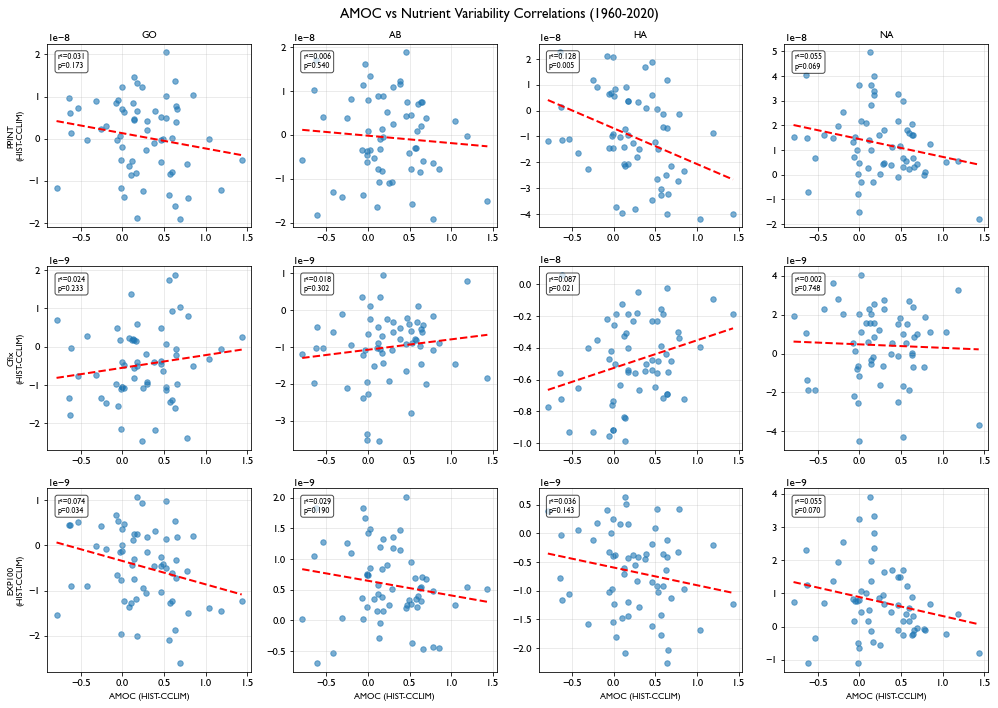


Correlation Results:
variable province         slope         r       r2  p_value
   PPINT       GO -3.636817e-09 -0.176842 0.031273 0.172763
   PPINT       AB -1.690410e-09 -0.080079 0.006413 0.539559
   PPINT       HA -1.383763e-08 -0.357602 0.127879 0.004664
   PPINT       NA -7.209487e-09 -0.234094 0.054800 0.069396
    Cflx       GO  3.316095e-10  0.154975 0.024017 0.233035
    Cflx       AB  2.824250e-10  0.134368 0.018055 0.301871
    Cflx       HA  1.746813e-09  0.295609 0.087385 0.020724
    Cflx       NA -1.793026e-10 -0.042015 0.001765 0.747831
  EXP100       GO -5.188963e-10 -0.271964 0.073964 0.033980
  EXP100       AB -2.394369e-10 -0.170252 0.028986 0.189587
  EXP100       HA -3.080370e-10 -0.189710 0.035990 0.143095
  EXP100       NA -5.716287e-10 -0.233961 0.054738 0.069560


In [44]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

MODELS = {
    'CCLIM': {'color': 'deepskyblue', 'id': 'TOM12_TJ_LC51'},
    'HIST': {'color': 'b', 'id': 'TOM12_TJ_LA50'},
    'HOSE': {'color': 'r', 'id': 'TOM12_TJ_LAH3'}
}

bdir = '/gpfs/data/greenocean/users/mep22dku/clims/'
mods = ['CCLIM', 'HIST']
provinces = ['GO', 'AB', 'HA', 'NA']
variables = [('PPINT', 'PPINT'), ('Cflx', 'Cflx'), ('EXP100', 'EXP')]

# Load and process AMOC
AMOC = {mod: xr.open_dataset(f'{bdir}/{MODELS[mod]["id"]}/{MODELS[mod]["id"]}_AMOC_1940_2020.nc') for mod in mods}
AMOC_yearly = {mod: AMOC[mod].resample(time_counter='Y').mean() for mod in mods}
AMOC_diff = AMOC_yearly['HIST'].AMOC - AMOC_yearly['CCLIM'].AMOC

# Process each variable
results = []

for tvar, tvar2 in variables:
    # Load variable data
    VAR = {}
    for mod in mods:
        mid = MODELS[mod]['id']
        try:
            VAR[mod] = xr.open_dataset(f'{bdir}/{mid}/{mid}_ptrc_{tvar}_d0_provinces.nc')
        except:
            VAR[mod] = xr.open_dataset(f'{bdir}/{mid}/{mid}_diad_{tvar}_dNone_provinces.nc')
        time_pd = pd.to_datetime([pd.Timestamp(t.isoformat()) for t in VAR[mod].time_counter.values])
        VAR[mod] = VAR[mod].assign_coords(time_counter=time_pd)
    
    # Compute yearly averages and differences
    VAR_yearly = {mod: VAR[mod].resample(time_counter='Y').mean() for mod in mods}
    VAR_diff = VAR_yearly['HIST'][tvar2] - VAR_yearly['CCLIM'][tvar2]
    
    # Linear regression for each province (1960-2020)
    for prov in provinces:
        var_prov = VAR_diff.sel(province=prov, time_counter=slice('1960', '2020'))
        amoc_prov = AMOC_diff.sel(time_counter=slice('1960', '2020'))
        
        # Align time dimensions
        common_times = np.intersect1d(var_prov.time_counter.values, amoc_prov.time_counter.values)
        var_vals = var_prov.sel(time_counter=common_times).values
        amoc_vals = amoc_prov.sel(time_counter=common_times).values
        
        # Linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(amoc_vals, var_vals)
        
        results.append({
            'variable': tvar,
            'province': prov,
            'slope': slope,
            'r': r_value,
            'r2': r_value**2,
            'p_value': p_value
        })

# Create results DataFrame
df_results = pd.DataFrame(results)
df_results.to_csv('./data/amoc_nutrient_correlations.csv', index=False)

# Visualize correlations
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for row_idx, (tvar, tvar2) in enumerate(variables):
    VAR = {}
    for mod in mods:
        mid = MODELS[mod]['id']
        try:
            VAR[mod] = xr.open_dataset(f'{bdir}/{mid}/{mid}_ptrc_{tvar}_d0_provinces.nc')
        except:
            VAR[mod] = xr.open_dataset(f'{bdir}/{mid}/{mid}_diad_{tvar}_dNone_provinces.nc')
        time_pd = pd.to_datetime([pd.Timestamp(t.isoformat()) for t in VAR[mod].time_counter.values])
        VAR[mod] = VAR[mod].assign_coords(time_counter=time_pd)
    
    VAR_yearly = {mod: VAR[mod].resample(time_counter='Y').mean() for mod in mods}
    VAR_diff = VAR_yearly['HIST'][tvar2] - VAR_yearly['CCLIM'][tvar2]
    
    for col_idx, prov in enumerate(provinces):
        ax = axes[row_idx, col_idx]
        
        var_prov = VAR_diff.sel(province=prov, time_counter=slice('1960', '2020'))
        amoc_prov = AMOC_diff.sel(time_counter=slice('1960', '2020'))
        
        common_times = np.intersect1d(var_prov.time_counter.values, amoc_prov.time_counter.values)
        var_vals = var_prov.sel(time_counter=common_times).values
        amoc_vals = amoc_prov.sel(time_counter=common_times).values
        
        # Scatter plot
        ax.scatter(amoc_vals, var_vals, alpha=0.6, s=30)
        
        # Add regression line
        slope, intercept, r_value, p_value, _ = stats.linregress(amoc_vals, var_vals)
        x_line = np.array([amoc_vals.min(), amoc_vals.max()])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'r--', linewidth=2)
        
        # Add statistics
        ax.text(0.05, 0.95, f'r²={r_value**2:.3f}\np={p_value:.3f}', 
                transform=ax.transAxes, va='top', fontsize=8, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        if row_idx == 0:
            ax.set_title(prov, fontsize=10, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(f'{tvar}\n(HIST-CCLIM)', fontsize=9)
        if row_idx == 2:
            ax.set_xlabel('AMOC (HIST-CCLIM)', fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle('AMOC vs Nutrient Variability Correlations (1960-2020)', fontsize=14)
plt.tight_layout()
plt.savefig('./data/amoc_nutrient_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation Results:")
print(df_results.to_string(index=False))

## hist only

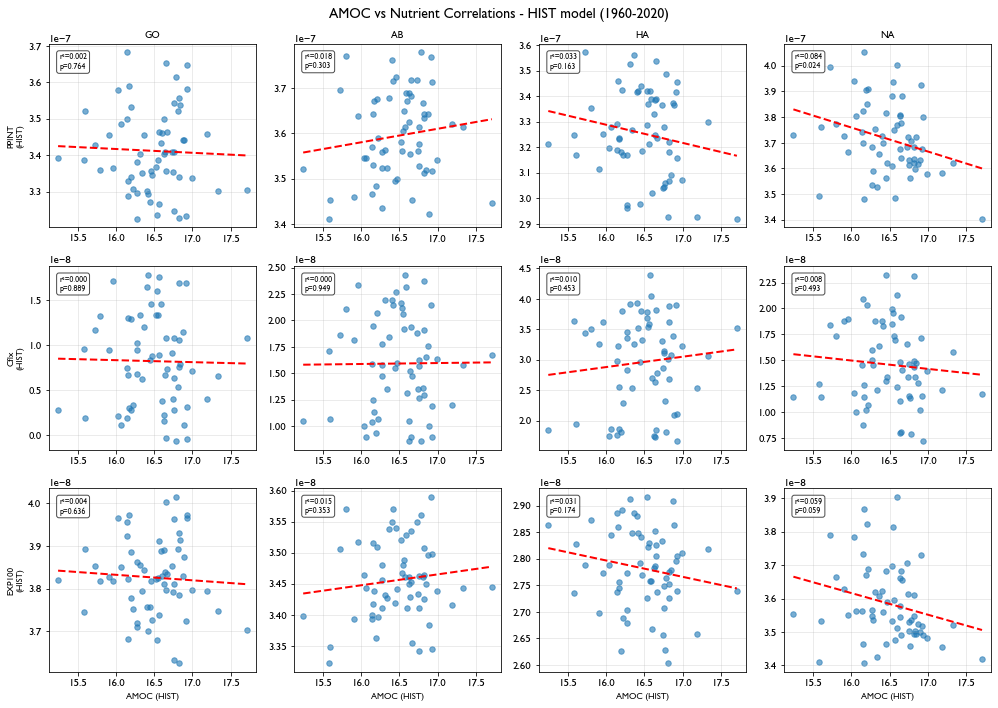


Correlation Results:
variable province         slope         r       r2  p_value
   PPINT       GO -1.036565e-09 -0.039304 0.001545 0.763612
   PPINT       AB  2.969928e-09  0.134113 0.017986 0.302798
   PPINT       HA -7.103855e-09 -0.180781 0.032682 0.163241
   PPINT       NA -9.321148e-09 -0.289547 0.083837 0.023613
    Cflx       GO -2.186489e-10 -0.018317 0.000336 0.888571
    Cflx       AB  8.893813e-11  0.008417 0.000071 0.948666
    Cflx       HA  1.697177e-09  0.097882 0.009581 0.452969
    Cflx       NA -8.053150e-10 -0.089552 0.008020 0.492503
  EXP100       GO -1.285599e-10 -0.061876 0.003829 0.635698
  EXP100       AB  1.750771e-10  0.121018 0.014645 0.352864
  EXP100       HA -3.069965e-10 -0.176463 0.031139 0.173700
  EXP100       NA -6.464631e-10 -0.242704 0.058905 0.059477


In [45]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

MODELS = {
    'CCLIM': {'color': 'deepskyblue', 'id': 'TOM12_TJ_LC51'},
    'HIST': {'color': 'b', 'id': 'TOM12_TJ_LA50'},
    'HOSE': {'color': 'r', 'id': 'TOM12_TJ_LAH3'}
}

bdir = '/gpfs/data/greenocean/users/mep22dku/clims/'
mods = ['HIST']
provinces = ['GO', 'AB', 'HA', 'NA']
variables = [('PPINT', 'PPINT'), ('Cflx', 'Cflx'), ('EXP100', 'EXP')]

# Load and process AMOC
AMOC = xr.open_dataset(f'{bdir}/{MODELS["HIST"]["id"]}/{MODELS["HIST"]["id"]}_AMOC_1940_2020.nc')
AMOC_yearly = AMOC.resample(time_counter='Y').mean()

# Process each variable
results = []

for tvar, tvar2 in variables:
    # Load variable data
    mid = MODELS['HIST']['id']
    try:
        VAR = xr.open_dataset(f'{bdir}/{mid}/{mid}_ptrc_{tvar}_d0_provinces.nc')
    except:
        VAR = xr.open_dataset(f'{bdir}/{mid}/{mid}_diad_{tvar}_dNone_provinces.nc')
    time_pd = pd.to_datetime([pd.Timestamp(t.isoformat()) for t in VAR.time_counter.values])
    VAR = VAR.assign_coords(time_counter=time_pd)
    
    # Compute yearly averages
    VAR_yearly = VAR.resample(time_counter='Y').mean()
    
    # Linear regression for each province (1960-2020)
    for prov in provinces:
        var_prov = VAR_yearly[tvar2].sel(province=prov, time_counter=slice('1960', '2020'))
        amoc_prov = AMOC_yearly.AMOC.sel(time_counter=slice('1960', '2020'))
        
        # Align time dimensions
        common_times = np.intersect1d(var_prov.time_counter.values, amoc_prov.time_counter.values)
        var_vals = var_prov.sel(time_counter=common_times).values
        amoc_vals = amoc_prov.sel(time_counter=common_times).values
        
        # Linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(amoc_vals, var_vals)
        
        results.append({
            'variable': tvar,
            'province': prov,
            'slope': slope,
            'r': r_value,
            'r2': r_value**2,
            'p_value': p_value
        })

# Create results DataFrame
df_results = pd.DataFrame(results)
df_results.to_csv('./data/amoc_nutrient_correlations.csv', index=False)

# Visualize correlations
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for row_idx, (tvar, tvar2) in enumerate(variables):
    mid = MODELS['HIST']['id']
    try:
        VAR = xr.open_dataset(f'{bdir}/{mid}/{mid}_ptrc_{tvar}_d0_provinces.nc')
    except:
        VAR = xr.open_dataset(f'{bdir}/{mid}/{mid}_diad_{tvar}_dNone_provinces.nc')
    time_pd = pd.to_datetime([pd.Timestamp(t.isoformat()) for t in VAR.time_counter.values])
    VAR = VAR.assign_coords(time_counter=time_pd)
    
    VAR_yearly = VAR.resample(time_counter='Y').mean()
    
    for col_idx, prov in enumerate(provinces):
        ax = axes[row_idx, col_idx]
        
        var_prov = VAR_yearly[tvar2].sel(province=prov, time_counter=slice('1960', '2020'))
        amoc_prov = AMOC_yearly.AMOC.sel(time_counter=slice('1960', '2020'))
        
        common_times = np.intersect1d(var_prov.time_counter.values, amoc_prov.time_counter.values)
        var_vals = var_prov.sel(time_counter=common_times).values
        amoc_vals = amoc_prov.sel(time_counter=common_times).values
        
        # Scatter plot
        ax.scatter(amoc_vals, var_vals, alpha=0.6, s=30)
        
        # Add regression line
        slope, intercept, r_value, p_value, _ = stats.linregress(amoc_vals, var_vals)
        x_line = np.array([amoc_vals.min(), amoc_vals.max()])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'r--', linewidth=2)
        
        # Add statistics
        ax.text(0.05, 0.95, f'r²={r_value**2:.3f}\np={p_value:.3f}', 
                transform=ax.transAxes, va='top', fontsize=8, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        if row_idx == 0:
            ax.set_title(prov, fontsize=10, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(f'{tvar}\n(HIST)', fontsize=9)
        if row_idx == 2:
            ax.set_xlabel('AMOC (HIST)', fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle('AMOC vs Nutrient Correlations - HIST model (1960-2020)', fontsize=14)
plt.tight_layout()
plt.savefig('./data/amoc_nutrient_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation Results:")
print(df_results.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12))

provinces = ['HA', 'NA', 'AB', 'GO']
variables = ['NO3', 'PO4', 'Si']

times = pd.to_datetime([str(t) for t in LA50_ptrc.time_counter.values])

for i, prov in enumerate(provinces):
    for j, var in enumerate(variables):
        data = LA50_ptrc[var].sel(province=prov)
        axes[i, j].plot(times, data.values)
        axes[i, j].set_title(f'{var} - {prov}')
        axes[i, j].set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure()
plt.